In [58]:
import numpy as np

import torch
import torch.nn as nn

import torch.optim as optim


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import pandas as pd


from tqdm import tqdm


from torch.utils.data import DataLoader, TensorDataset

In [43]:
HIDDEN_STATE_SHAPE = 8

In [44]:
# Hyperparameters
batch_size  = 1
seq_len     = 24
input_size  = 1   # dimensionality of each input vector
hidden_size = 8   # size of hidden state
num_layers  = 1   # single‐layer RNN

# Define the RNN module
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, output_size=1, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity='tanh',
            batch_first=True
        )
        # read-out layer: hidden_size → output_size
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None):
        # x: (batch, seq_len, input_size)
        # h0: (num_layers, batch, hidden_size), defaults to zeros if None
        out, h_n = self.rnn(x, h0)  
        # out: (batch, seq_len, hidden_size)
        # h_n: (num_layers, batch, hidden_size)

        # 1) If you only care about the last time-step prediction:
        last_hidden = out[:, -1, :]           # (batch, hidden_size)
        y_last = self.fc(last_hidden)         # (batch, output_size)

        # 2) If you want a prediction at every time step:
        # y_seq = self.fc(out)                # (batch, seq_len, output_size)

        return y_last, out, h_n

In [45]:
data = pd.read_csv("temperature.csv")
data.Year = pd.to_datetime(data.Year)

#Train
X = data.Anomaly[data.Year < pd.to_datetime("2000") ].to_numpy()
XYears = data.Year[data.Year < pd.to_datetime("2000") ].to_numpy()
#Test
TX = data.Anomaly[data.Year >= pd.to_datetime("2000") ].to_numpy()
TXYears = data.Year[data.Year >= pd.to_datetime("2000") ].to_numpy()

# MinMax Normalize\
M,m = X.max(), X.min()
X = X - m
X = X / (M - m)

In [68]:
# 24 Month long sequences
SEQLEN = 24
Xtrain = np.array([X[i:i+SEQLEN] for i in range(X.shape[0] - SEQLEN - 1)], dtype=float)
Ytrain = np.array([X[i+SEQLEN] for i in range(X.shape[0] - SEQLEN - 1)], dtype=float)


#Xtest
Xtest = np.array([TX[i:i+SEQLEN] for i in range(TX.shape[0] - SEQLEN - 1)])


Xtrain = Xtrain.reshape(*Xtrain.shape, 1)
Xtest = Xtest.reshape(*Xtest.shape,1)

Xtrain = torch.tensor(Xtrain, dtype=torch.float32)
Xtest = torch.tensor(Xtest, dtype=torch.float32)
Ytrain = torch.tensor(Ytrain, dtype=torch.float32)

dataset = TensorDataset(Xtrain, Ytrain)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [69]:
for i in range(len(Ytrain)-1):
    assert Ytrain[i] == Xtrain[i+1][-1]

In [70]:
# Initial hidden state: shape (num_layers, batch_size, hidden_size)
h0 = torch.zeros(num_layers, batch_size, hidden_size)

model = RNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [72]:
num_epochs = 100
N = 100
# Training loop
for epoch in range(1, num_epochs + 1):
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        y_pred, _, _ = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= N
    print(f"Epoch {epoch}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/100, Loss: 0.0788
Epoch 2/100, Loss: 0.0712
Epoch 3/100, Loss: 0.0706
Epoch 4/100, Loss: 0.0683
Epoch 5/100, Loss: 0.0692
Epoch 6/100, Loss: 0.0677
Epoch 7/100, Loss: 0.0685
Epoch 8/100, Loss: 0.0683
Epoch 9/100, Loss: 0.0679
Epoch 10/100, Loss: 0.0674
Epoch 11/100, Loss: 0.0669
Epoch 12/100, Loss: 0.0673
Epoch 13/100, Loss: 0.0676
Epoch 14/100, Loss: 0.0674
Epoch 15/100, Loss: 0.0669
Epoch 16/100, Loss: 0.0669
Epoch 17/100, Loss: 0.0671
Epoch 18/100, Loss: 0.0674
Epoch 19/100, Loss: 0.0669
Epoch 20/100, Loss: 0.0676
Epoch 21/100, Loss: 0.0673
Epoch 22/100, Loss: 0.0666
Epoch 23/100, Loss: 0.0667
Epoch 24/100, Loss: 0.0664
Epoch 25/100, Loss: 0.0665
Epoch 26/100, Loss: 0.0663
Epoch 27/100, Loss: 0.0665
Epoch 28/100, Loss: 0.0668
Epoch 29/100, Loss: 0.0666
Epoch 30/100, Loss: 0.0662
Epoch 31/100, Loss: 0.0660
Epoch 32/100, Loss: 0.0658
Epoch 33/100, Loss: 0.0673
Epoch 34/100, Loss: 0.0664
Epoch 35/100, Loss: 0.0664
Epoch 36/100, Loss: 0.0666
Epoch 37/100, Loss: 0.0665
Epoch 38/1

In [91]:
model(Xtrain)[0].reshape(-1).detach().numpy()

array([0.43793395, 0.39212808, 0.40804955, ..., 0.67583096, 0.71253204,
       0.69323564], shape=(1775,), dtype=float32)

Text(0.5, 1.0, 'Train Partition')

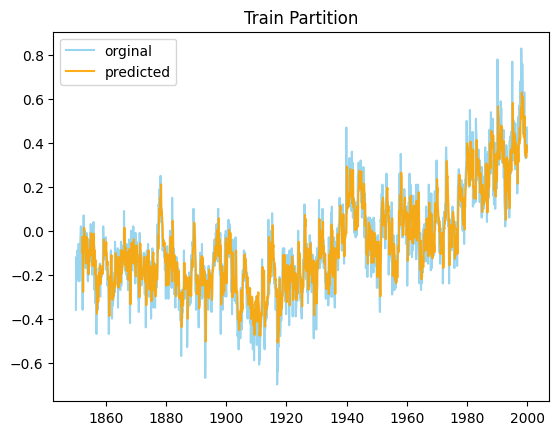

In [92]:
sns.lineplot(x=XYears, y=X*(M-m)+m, alpha=0.85, color="skyblue", label="orginal")
sns.lineplot(x=XYears[SEQLEN+1:],y=model(Xtrain)[0].reshape(-1).detach().numpy()*(M-m)+m, alpha=0.9,color="orange", label="predicted")
plt.title("Train Partition")

(np.float64(10957.0), np.float64(14610.0))

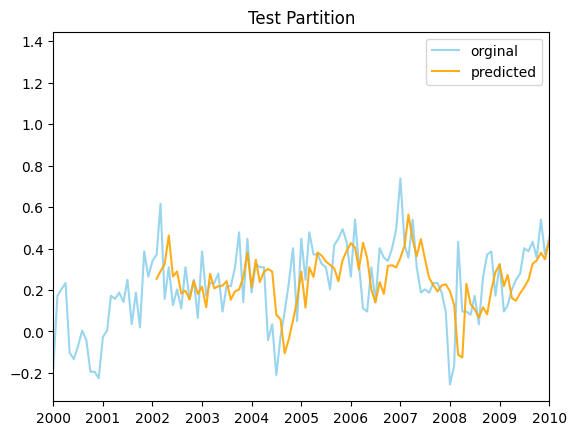

In [93]:
sns.lineplot(x=TXYears, y=TX*(M-m)+m, alpha=0.85, color="skyblue", label="orginal")
sns.lineplot(x=TXYears[SEQLEN+1:],y=model(Xtest)[0].reshape(-1).detach().numpy()*(M-m)+m, alpha=0.9,color="orange", label="predicted")
plt.title("Test Partition")
plt.xlim(pd.to_datetime("2000"), pd.to_datetime("2010"))

torch.Size([1, 24, 1])


Text(0.5, 1.0, 'Predicting 36 months into the future')

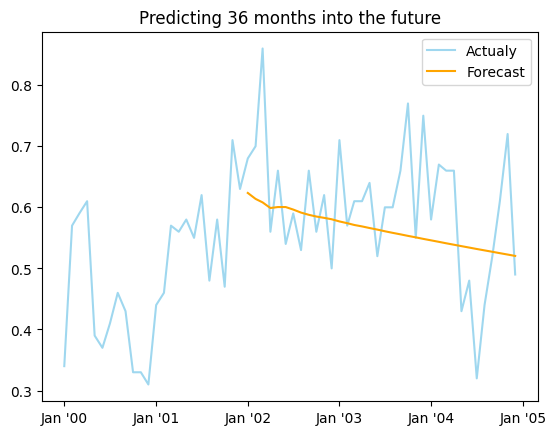

In [130]:
# Predicting three years into the future
PREDLEN = 36
_X = Xtest[0:1]
print(_X.shape)
for i in range(PREDLEN):
    _out = model(_X[-SEQLEN:])[0].reshape(1,1,1)
    _X = torch.cat([_X, _out], dim=1)
    

_X = _X.reshape(-1).detach().numpy()
    
sns.lineplot(x=TXYears[:SEQLEN+PREDLEN], y=TX[:SEQLEN+PREDLEN], alpha=0.8, color="skyblue", label="Actualy")
sns.lineplot(x=TXYears[SEQLEN:SEQLEN+PREDLEN],y=_X[SEQLEN:SEQLEN+PREDLEN], color="orange", label="Forecast")
ax = plt.gca() 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

plt.title("Predicting 36 months into the future")